<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
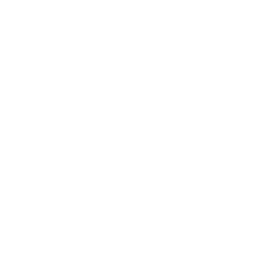
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Monitoreo del Proceso de Laminación en la Acería</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; SPC multivariante para el control de espesor y calidad superficial en el laminador de tiras en caliente &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Un laminador de tiras en caliente lamina planchones de acero hasta
convertirlos en bobinas delgadas. Seis señales de proceso
correlacionadas (espesores, fuerza de laminación, separación de
rodillos, corriente del motor, temperatura de salida) se mueven juntas
cuando la línea está sana, por lo que monitorearlas una gráfica a la
vez pasa por alto los desplazamientos conjuntos que importan. Este
ejemplo construye una línea base multivariante con **PROC MVPMODEL** y
luego transmite 100 bobinas de producción a través de **PROC
MVPMONITOR**, que puntúa cada bobina con un único estadístico
*T*&sup2; de Hotelling y lo compara con un límite de control.

Frente a un límite en control de *T*&sup2; = **17.13** (&alpha; =
0.05), **4 de 100 bobinas** señalan fuera de control — las bobinas
**91, 92, 94 y 95** — exactamente la ventana donde se inyectó una
ráfaga de traqueteo del rodillo de respaldo. El *T*&sup2; máximo
alcanza **21.91** en la bobina 95, aproximadamente **1.3&times;** el
límite. La rampa gradual de desgaste de rodillos en las bobinas
posteriores eleva el *T*&sup2; de referencia, pero se mantiene por
debajo del límite hasta el evento de traqueteo, de modo que la gráfica
separa claramente la deriva lenta de la falla aguda que requiere
atención inmediata.


## Fuentes de Datos

- **mill_baseline** &mdash; 50 bobinas laminadas durante un tramo
  conocido como bueno de la campaña; se usa para ajustar el modelo de
  referencia multivariante (ACP).
- **mill_stream** &mdash; 100 bobinas de la línea en vivo. Las bobinas
  1&ndash;55 operan en control; el desgaste de rodillos se desarrolla
  gradualmente en las bobinas 56&ndash;100; una ráfaga de traqueteo del
  rodillo de respaldo golpea las bobinas 91&ndash;95.
- **Variables de proceso** (6): `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> El entorno se ejecuta sin licencia, por lo que los conjuntos de datos
> están limitados a 100 observaciones. El escenario está dimensionado
> para ese límite: la perturbación se ubica al final de una secuencia
> de 100 bobinas en lugar de en la bobina 2800 de 5000.


---

### Paso 1 &mdash; Construir el modelo de referencia multivariante

`PROC MVPMODEL` realiza un análisis de componentes principales de las
seis variables de proceso sobre la línea base en control y escribe las
cargas, los valores propios y el centrado/escalado en `mill_model`. Se
retienen tres componentes. Este modelo define cómo se ve lo "normal"
como una única región multivariante en lugar de seis rangos
independientes.


In [1]:
DATOS mill_baseline;
  LLAMAR streaminit(66);
  HACER coil_id = 1 HASTA 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    SALIDA;
  END;
EJECUTAR;

PROCEDIMIENTO mvpmodel DATOS=mill_baseline outmodel=mill_model;
  VAR entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ncomp=3;
EJECUTAR;



                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         entry_thicknessexit_thicknessrolling_force  roll_gapmotor_current exit_temp
  entry_thickness    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  exit_thickness   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  rolling_force   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  roll_gap   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  motor_current    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  exit_temp    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    3


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---

### Paso 2 &mdash; Transmitir las bobinas de producción y puntuarlas

`PROC MVPMONITOR` proyecta cada una de las 100 bobinas de producción
sobre el modelo guardado y calcula su *T*&sup2; de Hotelling. El
procedimiento deriva el límite de control a partir de las dimensiones
del modelo y el &alpha; = 0.05 predeterminado, y luego marca cualquier
bobina cuyo *T*&sup2; lo supere. Los resultados, incluidas las columnas
`_TSQUARED`, `_LIMIT` y `_SIGNAL`, se escriben en `mill_scores`
indexados por `coil_id`.


In [2]:
DATOS mill_stream;
  LLAMAR streaminit(42);
  HACER coil_id = 1 HASTA 100;
    /* el desgaste de rodillos aumenta de 0 a 1 en las bobinas 56-100 */
    wear    = MAX(0, coil_id - 55) / 45;
    /* ráfaga de traqueteo del rodillo de respaldo en las bobinas 91-95 */
    chatter = (coil_id >= 91 AND coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    ELIMINAR wear chatter;
    SALIDA;
  END;
EJECUTAR;

PROCEDIMIENTO mvpmonitor DATOS=mill_stream model=mill_model
                out=mill_scores;
  VAR entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
EJECUTAR;



                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


El resumen del procedimiento informa el límite de control y el conteo
de señales. A continuación, el fragmento impreso alrededor de la
perturbación muestra que las bobinas de referencia se ubican muy por
debajo del límite, mientras que la ventana de traqueteo empuja a cuatro
bobinas por encima de él.


In [3]:
/* Marcar las bobinas fuera de control y capturar el T2 de alarma para graficar */
DATOS mill_scores;
  ESTABLECER mill_scores;
  SI _SIGNAL = 1 ENTONCES t2_alarm = _TSQUARED;
  SINO t2_alarm = .;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=mill_scores(firstobs=88 obs=96) noobs;
  VAR coil_id _TSQUARED _LIMIT _SIGNAL;
  ETIQUETA coil_id='ID de Bobina' _TSQUARED='T2' _LIMIT='Límite' _SIGNAL='Señal';
  TÍTULO 'Puntuaciones T2 en la ventana de traqueteo (bobinas 88-96)';
EJECUTAR;


                               Puntuaciones T2 en la ventana de traqueteo (bobinas 88-96)                               

ID de Bobina         T2     Límite   Señal
          88   9.983151  17.133408       0
          89   2.915646  17.133408       0
          90    7.80613  17.133408       0
          91  18.813814  17.133408       1
          92  18.249361  17.133408       1
          93  16.638221  17.133408       0
          94  17.981792  17.133408       1
          95  21.912329  17.133408       1
          96   5.118574  17.133408       0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---

### Paso 3 &mdash; Gráfico de control multivariante

El gráfico superpone el *T*&sup2; de cada bobina contra su límite de
control. Las bobinas fuera de control se resaltan en rojo; el marcador
vertical discontinuo señala el inicio de la ráfaga de traqueteo. El
ascenso lento hacia la derecha es el desgaste de rodillos elevando la
referencia; los cuatro puntos rojos son la falla aguda de traqueteo.


                               Puntuaciones T2 en la ventana de traqueteo (bobinas 88-96)                               




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


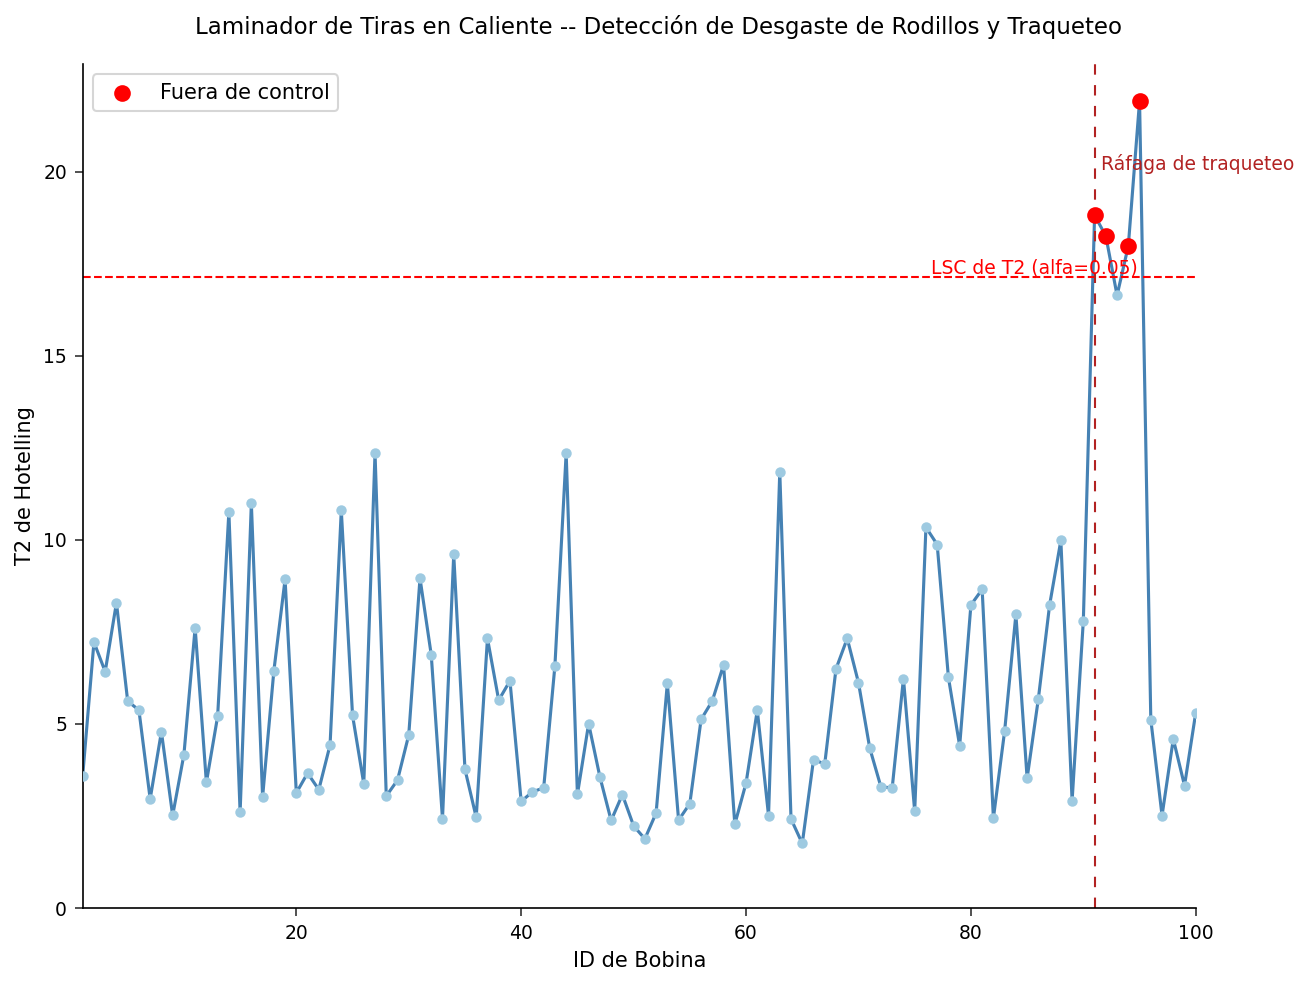

In [4]:
PROCEDIMIENTO SGPLOT DATOS=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel='Fuera de control';
  REFLINE _LIMIT / AXIS=y
          ETIQUETA='LSC de T2 (alfa=0.05)'
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x ETIQUETA='Ráfaga de traqueteo'
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS ETIQUETA='ID de Bobina' MIN=1 MAX=100;
  YAXIS ETIQUETA='T2 de Hotelling' MIN=0;
  TÍTULO 'Laminador de Tiras en Caliente -- Detección de Desgaste de Rodillos y Traqueteo';
EJECUTAR;


---

### Paso 4 &mdash; Cuantificar las bobinas fuera de control

Las bobinas fuera de control se enrutan a un conjunto de datos separado
para el equipo de calidad. `PROC MEANS` contrasta el nivel de
*T*&sup2; de las bobinas marcadas frente a la población en control, y
las bobinas marcadas se exportan para el enrutamiento posterior de
desecho/reproceso.


In [5]:
DATOS mill_ooc;
  ESTABLECER mill_scores;
  SI _SIGNAL = 1;
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=mill_scores n mean MAX maxdec=2;
  CLASE _SIGNAL;
  VAR _TSQUARED;
  ETIQUETA _SIGNAL='Señal de Control' _TSQUARED='T2 de Hotelling';
  TÍTULO 'T2 por estado de control (0 = en control, 1 = señal)';
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=mill_ooc noobs;
  VAR coil_id _TSQUARED _LIMIT;
  ETIQUETA coil_id='ID de Bobina' _TSQUARED='T2' _LIMIT='Límite';
  TÍTULO 'Bobinas fuera de control marcadas para inspección';
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REPLACE;
EJECUTAR;


                                  T2 por estado de control (0 = en control, 1 = señal)                                  

                                                  The MEANS Procedure

                                     Analysis Variable : _TSQUARED T2 de Hotelling

        Señal de Control           N Obs           Mean        Maximum
        --------------------------------------------------------------
        0                             96           5.39          16.64
        1                              4          19.24          21.91
        --------------------------------------------------------------

                                   Bobinas fuera de control marcadas para inspección                                    

ID de Bobina         T2     Límite
          91  18.813814  17.133408
          92  18.249361  17.133408
          94  17.981792  17.133408
          95  21.912329  17.133408




NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## Hallazgos

- **Bobinas monitoreadas**: 100; **límite de control** *T*&sup2; =
  **17.13** (&alpha; = 0.05).
- **Bobinas fuera de control**: **4** &mdash; bobinas **91, 92, 94, 95**,
  todas dentro de la ventana de traqueteo inyectada (91&ndash;95). La
  bobina 93 alcanza un pico de *T*&sup2; = 16.64, justo por debajo del
  límite.
- **Severidad máxima**: *T*&sup2; = **21.91** en la bobina 95
  (aproximadamente 1.3&times; el límite); las bobinas en control
  promedian *T*&sup2; &asymp; **5.4**.
- **Desgaste vs. falla**: la rampa gradual de desgaste de rodillos eleva
  la referencia de las bobinas posteriores, pero nunca cruza el límite
  por sí sola, de modo que el gráfico multivariante único distingue la
  deriva lenta (vigilar) del evento agudo de traqueteo (actuar).
- **Acción**: las cuatro bobinas marcadas se exportan a
  `steel_mill_ooc_coils.csv` para inspección y enrutamiento de
  desecho/reproceso; la firma de traqueteo apunta al rodamiento del
  rodillo de respaldo para inspección antes de la próxima campaña.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>